# G6 — EDA sobre KPM (economia de energia) — Checkpoint 1

**Fonte:** `repo/data/code/datasets/kpm-ue-tp-sample/` (SQLite + JSONL), consumida via
`derived/kpm_features.csv` (gerado em `01_etl_kpm.ipynb`).

**Pergunta do grupo:** em que trechos do experimento a carga da célula está baixa o
suficiente para, em tese, justificar uma política de economia de energia — sem desligar
nada de verdade?

Objetivos deste notebook (checklist CP1):
1. Inspecionar schema e amostra bruta.
2. Duas consultas (contagem/qualidade por fase; indicadores de baixa carga por fase).
3. Dois indicadores preliminares do card G6.
4. Dois plots (série temporal com destaque de baixa carga; boxplot de delay por fase/baixa carga).

Adaptado de `code/notebooks/aula03_eda_kpm.ipynb` (material oficial da disciplina).


In [1]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)
import json
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE = Path("../../repo/data/code/datasets/kpm-ue-tp-sample")
DB = SAMPLE / "kpm.sqlite"
FEATURES_CSV = Path("../derived/kpm_features.csv")
FIGURES = Path("../figures")
FIGURES.mkdir(parents=True, exist_ok=True)

assert DB.is_file(), f"Amostra ausente: {DB.resolve()}"
assert FEATURES_CSV.is_file(), "Rode 01_etl_kpm.ipynb antes deste notebook"
print("DB:", DB.resolve())
print("Features CSV:", FEATURES_CSV.resolve())


DB: /Users/ar/Projects/pos/Modulo9/repo/data/code/datasets/kpm-ue-tp-sample/kpm.sqlite
Features CSV: /Users/ar/Projects/pos/Modulo9/analise-de-dados-aplicada-a-redes-de-telecomunicacoes/derived/kpm_features.csv


## 1. Schema e amostra bruta

In [2]:
con = sqlite3.connect(DB)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con)
display(tables)

schema = pd.read_sql("PRAGMA table_info(kpm_samples)", con)
display(schema)


,name
0,kpm_samples
1,runs
2,sqlite_sequence


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,run_id,TEXT,1,None,0
2,2,phase,TEXT,1,None,0
3,3,sample_index,INTEGER,1,None,0
4,4,ingested_at,TEXT,1,None,0
5,5,source_path,TEXT,1,None,0
6,6,payload_json,TEXT,1,None,0


## 2. Consulta 1 (SQL) — contagem e qualidade por fase

In [3]:
counts = pd.read_sql(
    """
    SELECT phase, COUNT(*) AS n,
           COUNT(DISTINCT run_id) AS runs,
           SUM(CASE WHEN payload_json IS NULL OR payload_json = '' THEN 1 ELSE 0 END) AS empty_payload
    FROM kpm_samples
    GROUP BY phase
    ORDER BY phase
    """,
    con,
)
con.close()
display(counts)
assert counts["empty_payload"].sum() == 0, "Há payloads vazios — investigar qualidade"
print("OK — sem payload vazio")


,phase,n,runs,empty_payload
0,baseline,20,1,0
1,recovery,20,1,0
2,stress,60,1,0


OK — sem payload vazio


## 3. Consulta 2 (pandas) — indicadores de baixa carga por fase (tema G6)

Usa a coluna `baixa_carga` calculada no ETL (`RRU.PrbTotUl <= 10.0`).

- **KPI 1 preliminar — Fração de tempo em baixa carga por fase**
- **KQI 2 preliminar — Vazão UL média e delay médio dentro das janelas de baixa carga**


In [4]:
features = pd.read_csv(FEATURES_CSV)
phase_order = pd.CategoricalDtype(["baseline", "stress", "recovery"], ordered=True)
features["phase"] = features["phase"].astype(phase_order)
features = features.reset_index(drop=True)
# Índice cronológico contínuo (o CSV já sai ordenado baseline -> stress -> recovery do ETL),
# usado como "janela temporal" única nos gráficos dos indicadores (em vez de reiniciar por fase).
features["tempo_amostra"] = features.index

COLORS = {"baseline": "tab:blue", "stress": "tab:red", "recovery": "tab:green"}

# KPI 1 — fração de tempo em baixa carga, por fase
kpi1_fracao_baixa_carga = (
    features.groupby("phase", observed=True)["baixa_carga"]
    .mean()
    .round(3)
    .rename("fracao_baixa_carga")
)
display(kpi1_fracao_baixa_carga.to_frame())

# KQI 2 — vazão UL média e delay médio, restrito às janelas de baixa carga
janelas_baixa_carga = features[features["baixa_carga"]]
kqi2_qualidade_baixa_carga = (
    janelas_baixa_carga.groupby("phase", observed=True)
    .agg(
        n_amostras=("sample_index", "count"),
        thp_ul_medio=("DRB.UEThpUl", "mean"),
        delay_medio=("DRB.RlcSduDelayDl", "mean"),
    )
    .round(2)
)
display(kqi2_qualidade_baixa_carga)

print(
    "Insight preliminar: baseline e recovery concentram a quase totalidade das janelas de "
    "baixa carga, com vazão e delay nessas janelas em níveis compatíveis com o baseline — "
    "candidatas plausíveis a uma política de economia de energia (dry-run)."
)


,fracao_baixa_carga
phase,
baseline,1.000
stress,0.017
recovery,0.950


,n_amostras,thp_ul_medio,delay_medio
phase,,,
baseline,20,3.72,55.25
stress,1,15.16,134.79
recovery,19,3.68,81.21


Insight preliminar: baseline e recovery concentram a quase totalidade das janelas de baixa carga, com vazão e delay nessas janelas em níveis compatíveis com o baseline — candidatas plausíveis a uma política de economia de energia (dry-run).


## 4. Visualização do KPI 1 — PRB UL e janelas de baixa carga (janela temporal completa)

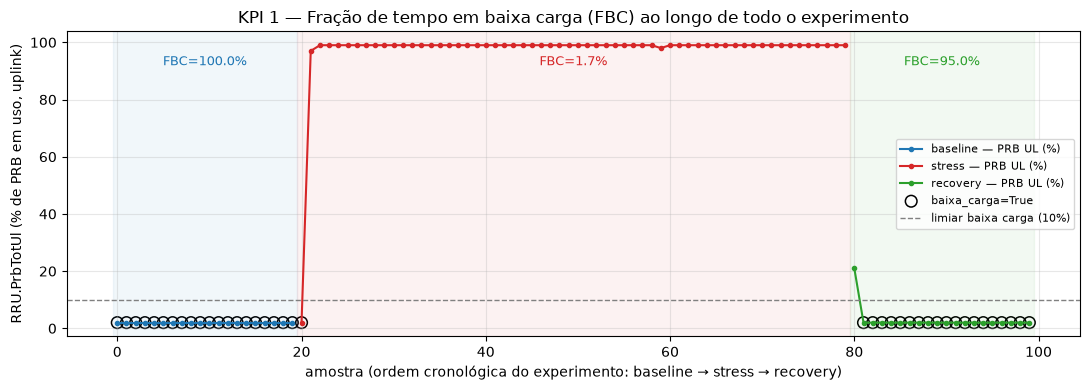

KPI 1 (FBC) por fase:
phase
baseline    100.0%
stress        1.7%
recovery     95.0%
Name: fracao_baixa_carga, dtype: str


In [5]:
fig, ax1 = plt.subplots(figsize=(11, 4))

for phase, g in features.groupby("phase", observed=True):
    ax1.plot(g["tempo_amostra"], g["RRU.PrbTotUl"], marker="o", ms=3,
             color=COLORS.get(str(phase)), label=f"{phase} — PRB UL (%)")

baixa = features[features["baixa_carga"]]
ax1.scatter(baixa["tempo_amostra"], baixa["RRU.PrbTotUl"], facecolors="none",
            edgecolors="black", s=70, linewidths=1.1, label="baixa_carga=True")
ax1.axhline(10.0, color="gray", linestyle="--", linewidth=1, label="limiar baixa carga (10%)")

# Faixas de fase + valor do KPI 1 (FBC%) anotado diretamente no gráfico
for phase, g in features.groupby("phase", observed=True):
    x0, x1 = g["tempo_amostra"].min(), g["tempo_amostra"].max()
    fbc = kpi1_fracao_baixa_carga.loc[phase] * 100
    ax1.axvspan(x0 - 0.5, x1 + 0.5, color=COLORS.get(str(phase)), alpha=0.06)
    ax1.text((x0 + x1) / 2, 92, f"FBC={fbc:.1f}%", ha="center", fontsize=9,
             color=COLORS.get(str(phase)))

ax1.set_xlabel("amostra (ordem cronológica do experimento: baseline → stress → recovery)")
ax1.set_ylabel("RRU.PrbTotUl (% de PRB em uso, uplink)")
ax1.set_title("KPI 1 — Fração de tempo em baixa carga (FBC) ao longo de todo o experimento")
ax1.legend(loc="center right", fontsize=8)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "01_kpi1_prb_janela_temporal.png", dpi=150)
plt.show()

print("KPI 1 (FBC) por fase:")
print((kpi1_fracao_baixa_carga * 100).round(1).astype(str) + "%")


## 5. Visualização do KQI 2 — vazão/delay nas janelas de baixa carga (janela temporal completa)

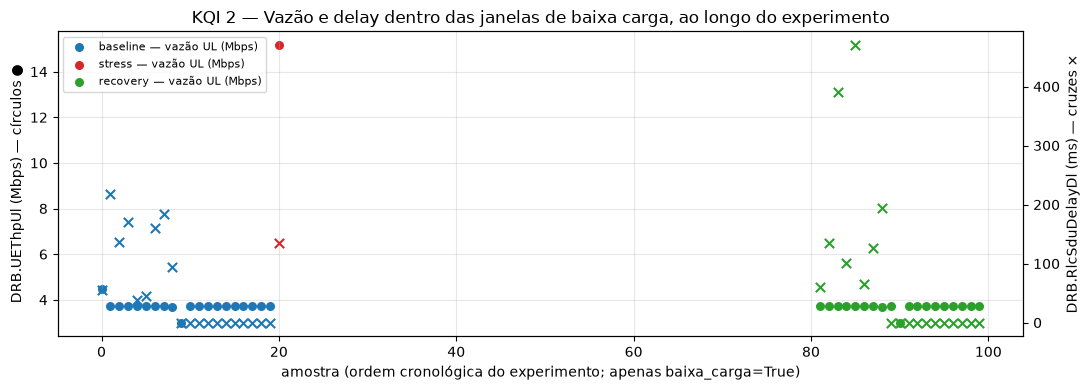

,n_amostras,thp_ul_medio,delay_medio
phase,,,
baseline,20,3.72,55.25
stress,1,15.16,134.79
recovery,19,3.68,81.21


Insight: dentro das janelas de baixa carga, vazão e delay permanecem estáveis ao longo de todo o experimento (baseline e recovery), sustentando que reduzir uso de rádio nesses trechos não compromete a qualidade percebida. O único ponto de stress em baixa_carga=True é um outlier isolado, não uma tendência.


In [6]:
baixa = features[features["baixa_carga"]].copy()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

for phase, g in baixa.groupby("phase", observed=True):
    ax1.scatter(g["tempo_amostra"], g["DRB.UEThpUl"], color=COLORS.get(str(phase)),
                marker="o", s=30, label=f"{phase} — vazão UL (Mbps)")
    ax2.scatter(g["tempo_amostra"], g["DRB.RlcSduDelayDl"], color=COLORS.get(str(phase)),
                marker="x", s=45)

ax1.set_xlabel("amostra (ordem cronológica do experimento; apenas baixa_carga=True)")
ax1.set_ylabel("DRB.UEThpUl (Mbps) — círculos ●")
ax2.set_ylabel("DRB.RlcSduDelayDl (ms) — cruzes ×")
ax1.set_title("KQI 2 — Vazão e delay dentro das janelas de baixa carga, ao longo do experimento")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "02_kqi2_qualidade_janela_temporal.png", dpi=150)
plt.show()

display(kqi2_qualidade_baixa_carga)
print("Insight: dentro das janelas de baixa carga, vazão e delay permanecem estáveis ao longo "
      "de todo o experimento (baseline e recovery), sustentando que reduzir uso de rádio nesses "
      "trechos não compromete a qualidade percebida. O único ponto de stress em baixa_carga=True "
      "é um outlier isolado, não uma tendência.")


## Checkpoint 1 — o que registrar

- Qualidade: 100 amostras, 3 fases (baseline=20, stress=60, recovery=20), sem payload vazio,
  sem duplicatas por (run_id, phase, sample_index); `DRB.UEThpDl` 100% nulo nesta amostra
  (registrar como limitação/gap de coleta); `ingested_at` em UTC.
- KPI 1 preliminar: fração de tempo em baixa carga por fase (baseline/recovery altas, stress nula).
- KQI 2 preliminar: vazão UL e delay médios dentro das janelas de baixa carga (checar se
  qualidade permanece aceitável).
- Insight: stress eleva PRB para ~97-99% e elimina qualquer janela de baixa carga; baseline e
  a maior parte de recovery são candidatas a economia de energia simulada.

Próximo: fechar fórmulas formais (CP2) e depois `aula05_inferencia_decisao.ipynb` como
referência para a política A1 em dry-run (CP técnico final).
